# Тематическое моделирование DialogSum-RU — SOTA-пайплайн

Этот блокнот выполняет тематический анализ колонки `topic` датасета [`d0rj/dialogsum-ru`](https://huggingface.co/datasets/d0rj/dialogsum-ru) с использованием современного прозрачного пайплайна:

1. **Векторные представления предложений** на основе многоязычной модели `sentence-transformers` (GPU, A100).
2. **Снижение размерности** через UMAP.
3. **Плотностная кластеризация** с помощью HDBSCAN (учитывает кластеры произвольной формы и выбросы).
4. **Интерпретация кластеров**: TF-IDF-ключевые слова + репрезентативные исходные темы + опционально LLM-сгенерированные `cluster_name` / `cluster_description`.
5. **Классические базовые модели** (LDA, NMF) для сравнения.

На выходе — аннотированная таблица, где каждая строка DialogSum-RU имеет стабильный `cluster_id`, понятное человеку `cluster_name` и `cluster_description`. Подходит для последующих задач: стратификация, объединение редких тем, построение иерархии меток, онлайн-присвоение кластеров новым диалогам.

> **Оборудование:** рассчитано на запуск на GPU A100 (Colab/Kaggle/локально). При отсутствии CUDA автоматически используется CPU.
> **Шаг с LLM:** по умолчанию отключён (`RUN_LLM_INTERPRETATION = False`). В качестве запасного варианта используется эвристическое именование по ключевым словам.

> **Данные:** все итоговые таблицы и графики сохраняются в Google Drive проекта по пути `/content/drive/MyDrive/russian-dialogue-intent-thesis/results/`. Перед запуском подключите Google Drive (ячейка ниже).

## Ячейка 1 — Установка зависимостей

In [ ]:
# ячейка 1: установка зависимостей
# Раскомментируйте при запуске в чистом окружении (Colab/Kaggle).
!pip install -q pandas numpy pyarrow matplotlib seaborn scikit-learn \
    sentence-transformers hdbscan umap-learn huggingface_hub fsspec \
    transformers accelerate bitsandbytes


## Ячейка 2 — Подключение Google Drive и пути к результатам

Подключаем Google Drive проекта и определяем пути для сохранения таблиц и графиков. Если блокнот выполняется вне Colab, импорт `google.colab` будет пропущен — в этом случае при сохранении результатов будет выброшена понятная ошибка с просьбой смонтировать Drive.

In [2]:
# ячейка 2: монтирование Google Drive и пути проекта
import os

try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive')
    print('Google Drive подключён.')
except ImportError:
    print('Окружение не Colab: пропускаем монтирование Google Drive.')
except Exception as e:
    print(f'Не удалось смонтировать Google Drive: {e}')

BASE_DIR = '/content/drive/MyDrive/russian-dialogue-intent-thesis'
RESULTS_DIR = f'{BASE_DIR}/results'
TABLES_DIR = f'{RESULTS_DIR}/tables'
FIGURES_DIR = f'{RESULTS_DIR}/figures'

for d in (RESULTS_DIR, TABLES_DIR, FIGURES_DIR):
    try:
        os.makedirs(d, exist_ok=True)
    except OSError as e:
        print(f'Не удалось создать каталог {d}: {e}')

print(f'BASE_DIR    = {BASE_DIR}')
print(f'TABLES_DIR  = {TABLES_DIR}')
print(f'FIGURES_DIR = {FIGURES_DIR}')

Mounted at /content/drive
Google Drive подключён.
BASE_DIR    = /content/drive/MyDrive/russian-dialogue-intent-thesis
TABLES_DIR  = /content/drive/MyDrive/russian-dialogue-intent-thesis/results/tables
FIGURES_DIR = /content/drive/MyDrive/russian-dialogue-intent-thesis/results/figures


## Ячейка 3 — Импорты и настройки

In [3]:
# ячейка 3: импорты и настройки
import re
import json
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sentence_transformers import SentenceTransformer
import umap
import hdbscan

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.metrics import silhouette_score

try:
    import torch
    HAS_TORCH = True
except ImportError:
    HAS_TORCH = False

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
if HAS_TORCH:
    torch.manual_seed(RANDOM_STATE)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(RANDOM_STATE)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 200)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')

DEVICE = 'cuda' if (HAS_TORCH and torch.cuda.is_available()) else 'cpu'
print(f'Устройство: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU:        {torch.cuda.get_device_name(0)}')

Устройство: cuda
GPU:        NVIDIA A100-SXM4-80GB


## Ячейка 4 — Загрузка и объединение DialogSum-RU

In [4]:
# ячейка 4: загрузка и объединение DialogSum-RU
HF_BASE = 'hf://datasets/d0rj/dialogsum-ru/'
SPLIT_PATHS = {
    'train': 'data/train-00000-of-00001-bcc43b46acda4001.parquet',
    'validation': 'data/validation-00000-of-00001-7e263d81db1c7a12.parquet',
    'test': 'data/test-00000-of-00001-2f13615b955ea947.parquet',
}

frames = []
for split, path in SPLIT_PATHS.items():
    df_part = pd.read_parquet(HF_BASE + path)
    df_part['split'] = split
    print(f'{split:>10}: {df_part.shape}')
    frames.append(df_part)

df_all = pd.concat(frames, ignore_index=True)
print(f'\nОбъединённый df_all, форма: {df_all.shape}')
print(f'Колонки: {list(df_all.columns)}')
print(f"\nПропуски в колонке topic: {df_all['topic'].isna().sum()}")
print('\nПримеры строк:')
df_all[['id', 'split', 'topic', 'summary']].head(5)

     train: (12460, 5)
validation: (500, 5)
      test: (1500, 5)

Объединённый df_all, форма: (14460, 5)
Колонки: ['id', 'dialogue', 'summary', 'topic', 'split']

Пропуски в колонке topic: 0

Примеры строк:


,id,split,topic,summary
0,train_0,train,пройти обследование,"Мистер Смит проходит обследование, и доктор Хокинс советует ему проходить его каждый год. Хокинс расскажет об их занятиях и лекарствах, которые помогут мистеру Смиту бросить курить."
1,train_1,train,вакцина,"Миссис Паркер берет Рики на прививки. Доктор Питерс проверяет записи, а затем делает Рики вакцину."
2,train_2,train,найти ключи,#Person1# ищет набор ключей и просит #Person2# помочь их найти.
3,train_3,train,иметь девушку,"#Person1# злится, потому что #Person2# не сказал #Person1#, что у #Person2# есть девушка и он женится на ней."
4,train_4,train,танец,"Малик приглашает Никки на танец. Никки соглашается, если Малик не против того, чтобы ему наступили на ноги."


## Ячейка 5 — Предобработка `topic`

In [5]:
# ячейка 5: предобработка topic
_RE_KEEP = re.compile(r'[^a-zA-Zа-яА-ЯёЁ0-9\s]+')
_RE_SPACE = re.compile(r'\s+')

def clean_topic(text):
    """Приводит к нижнему регистру, оставляет только буквы (рус./лат.), цифры и пробелы, схлопывает пробелы."""
    if text is None or (isinstance(text, float) and np.isnan(text)):
        return ''
    s = str(text).lower()
    s = _RE_KEEP.sub(' ', s)
    s = _RE_SPACE.sub(' ', s).strip()
    return s

df_all['topic_clean'] = df_all['topic'].map(clean_topic)

empty_mask = df_all['topic_clean'].str.len() == 0
print(f'Пустых значений topic_clean: {int(empty_mask.sum())} из {len(df_all)}')

df_model = df_all[df_all['topic_clean'].str.len() > 0].copy().reset_index(drop=True)
print(f'Размер обучающего набора: {df_model.shape}')
df_model[['topic', 'topic_clean']].head(10)

Пустых значений topic_clean: 0 из 14460
Размер обучающего набора: (14460, 6)


,topic,topic_clean
0,пройти обследование,пройти обследование
1,вакцина,вакцина
2,найти ключи,найти ключи
3,иметь девушку,иметь девушку
4,танец,танец
5,день рождения,день рождения
6,оплатить проезд,оплатить проезд
7,заявление о приеме на работу,заявление о приеме на работу
8,компьютерный пакет,компьютерный пакет
9,виза,виза


## Ячейка 6 — Векторные представления предложений

Используем многоязычный sentence-transformer (`paraphrase-multilingual-MiniLM-L12-v2`, 384-мерный), который напрямую работает с русским языком. Все очищенные темы кодируются на GPU и L2-нормализуются — косинусное расстояние в этом пространстве становится евклидовым, что и требуется для HDBSCAN после UMAP.

In [6]:
# ячейка 6: построение векторных представлений
EMBEDDING_MODEL_NAME = 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
BATCH_SIZE = 64  # комфортно для A100; уменьшите при нехватке памяти

embedder = SentenceTransformer(EMBEDDING_MODEL_NAME, device=DEVICE)
print(f'Загружена модель {EMBEDDING_MODEL_NAME} на устройстве {DEVICE}')

texts = df_model['topic_clean'].tolist()
embeddings = embedder.encode(
    texts,
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)
print(f'Форма эмбеддингов: {embeddings.shape}, тип: {embeddings.dtype}')

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Загружена модель sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2 на устройстве cuda


Batches:   0%|          | 0/226 [00:00<?, ?it/s]

Форма эмбеддингов: (14460, 384), тип: float32


## Ячейка 7 — Кластеризация UMAP + HDBSCAN

UMAP снижает размерность 384-мерных эмбеддингов до 5, чтобы плотностная кластеризация была устойчивой и быстрой; косинусная метрика согласована с геометрией эмбеддингов. HDBSCAN выделяет кластеры произвольной формы и помечает неуверенные точки как `-1` (выбросы), не загоняя каждый документ в кластер насильно.

In [7]:
# ячейка 7: кластеризация UMAP + HDBSCAN
UMAP_N_COMPONENTS = 5
UMAP_N_NEIGHBORS = 15
MIN_CLUSTER_SIZE = 30
MIN_SAMPLES = 10

reducer = umap.UMAP(
    n_neighbors=UMAP_N_NEIGHBORS,
    n_components=UMAP_N_COMPONENTS,
    min_dist=0.0,
    metric='cosine',
    random_state=RANDOM_STATE,
)
embeddings_umap = reducer.fit_transform(embeddings)
print(f'Форма после UMAP: {embeddings_umap.shape}')

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True,
)
cluster_labels = clusterer.fit_predict(embeddings_umap)
df_model['cluster_id'] = cluster_labels

if getattr(clusterer, 'probabilities_', None) is not None:
    df_model['cluster_probability'] = clusterer.probabilities_
if getattr(clusterer, 'outlier_scores_', None) is not None:
    df_model['outlier_score'] = clusterer.outlier_scores_

n_clusters = int(df_model.loc[df_model['cluster_id'] != -1, 'cluster_id'].nunique())
n_outliers = int((df_model['cluster_id'] == -1).sum())
print(f'Количество кластеров (без -1): {n_clusters}')
print(f'Выбросов (-1): {n_outliers} ({n_outliers / len(df_model):.1%})')

Форма после UMAP: (14460, 5)
Количество кластеров (без -1): 208
Выбросов (-1): 2477 (17.1%)


## Ячейка 8 — Размеры кластеров и метрики качества

Топ-25 размеров кластеров (cluster_id : количество):
cluster_id
-1      2477
 202     212
 77      167
 145     163
 204     154
 114     149
 186     132
 206     128
 169     119
 28      114
 187     113
 155     112
 181     109
 149     106
 71      106
 85      104
 117     103
 75      101
 108     100
 166      93
 29       91
 142      91
 98       90
 61       90
 162      89
Name: count, dtype: int64
График сохранён: /content/drive/MyDrive/russian-dialogue-intent-thesis/results/figures/dialogsum_ru_cluster_sizes.png


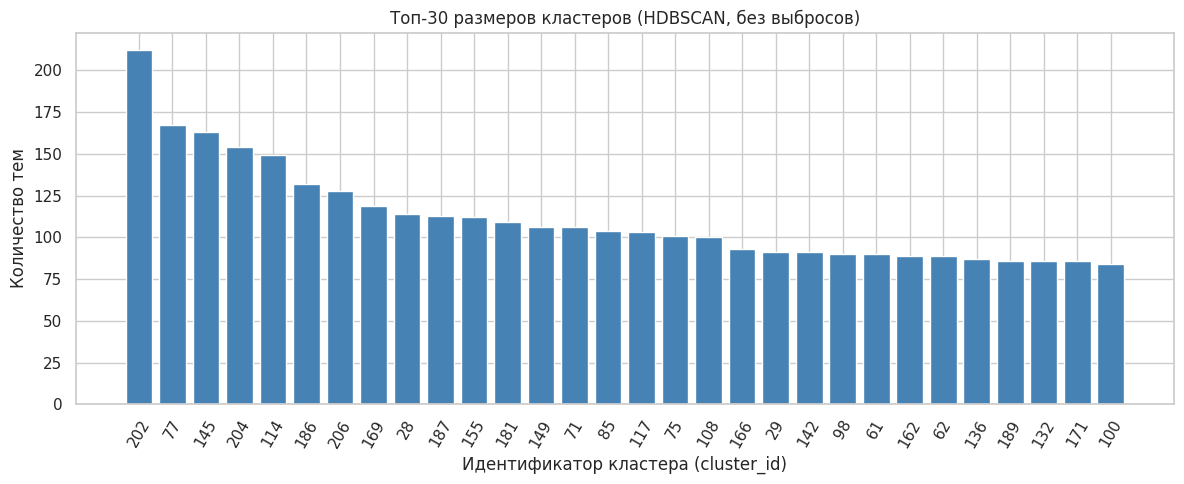

Силуэтная мера (UMAP-пространство, без -1): 0.7623


In [8]:
# ячейка 8: размеры кластеров и метрики качества
size_counts = df_model['cluster_id'].value_counts().sort_values(ascending=False)
print('Топ-25 размеров кластеров (cluster_id : количество):')
print(size_counts.head(25))

non_outlier_sizes = size_counts[size_counts.index != -1]
top_show = non_outlier_sizes.head(30)
if len(top_show) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(top_show.index.astype(str), top_show.values, color='steelblue')
    ax.set_title('Топ-30 размеров кластеров (HDBSCAN, без выбросов)')
    ax.set_xlabel('Идентификатор кластера (cluster_id)')
    ax.set_ylabel('Количество тем')
    plt.xticks(rotation=60)
    plt.tight_layout()
    try:
        fig_path = os.path.join(FIGURES_DIR, 'dialogsum_ru_cluster_sizes.png')
        fig.savefig(fig_path, dpi=150, bbox_inches='tight')
        print(f'График сохранён: {fig_path}')
    except OSError as e:
        print(f'Не удалось сохранить график размеров кластеров: {e}')
    plt.show()

# Силуэтная мера в пространстве UMAP (там же, где работал HDBSCAN), без -1.
# Ограничиваем выборку, чтобы расчёт оставался быстрым на больших данных.
sil = None
valid_mask = df_model['cluster_id'] != -1
if valid_mask.sum() >= 2 and df_model.loc[valid_mask, 'cluster_id'].nunique() >= 2:
    sample_idx = np.where(valid_mask.values)[0]
    if len(sample_idx) > 20000:
        sample_idx = np.random.RandomState(RANDOM_STATE).choice(sample_idx, 20000, replace=False)
    sil = float(silhouette_score(
        embeddings_umap[sample_idx],
        df_model['cluster_id'].values[sample_idx],
        metric='euclidean',
    ))
    print(f'Силуэтная мера (UMAP-пространство, без -1): {sil:.4f}')
else:
    print('Силуэтная мера: не вычисляется (нужно >= 2 кластеров с >= 2 документами).')

## Ячейка 9 — Ключевые слова и репрезентативные примеры

Для каждого кластера считаем TF-IDF по объединённым темам и берём топ n-грамм. Репрезентативные темы отбираются по вероятности принадлежности HDBSCAN (если доступна); иначе берём первые строки кластера.

In [9]:
# ячейка 9: ключевые слова и репрезентативные примеры
TOP_K_KEYWORDS = 10
TOP_K_EXAMPLES = 5

# Один псевдо-документ на кластер (включая -1 для наглядности)
cluster_docs = (
    df_model.groupby('cluster_id')['topic_clean']
    .apply(lambda s: ' '.join(s.tolist()))
    .sort_index()
)
cluster_ids_sorted = cluster_docs.index.tolist()

kw_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=5000,
)
tfidf_matrix = kw_vectorizer.fit_transform(cluster_docs.values)
kw_vocab = np.array(kw_vectorizer.get_feature_names_out())

def top_keywords_for_row(row, k=TOP_K_KEYWORDS):
    arr = row.toarray().ravel()
    if arr.sum() == 0:
        return []
    idx = np.argsort(-arr)[:k]
    return [kw_vocab[i] for i in idx if arr[i] > 0]

rows = []
for pos, cid in enumerate(cluster_ids_sorted):
    sub = df_model[df_model['cluster_id'] == cid]
    keywords = top_keywords_for_row(tfidf_matrix[pos])
    if 'cluster_probability' in sub.columns:
        sub_sorted = sub.sort_values('cluster_probability', ascending=False)
    else:
        sub_sorted = sub
    examples = sub_sorted['topic'].head(TOP_K_EXAMPLES).tolist()
    rows.append({
        'cluster_id': int(cid),
        'cluster_size': int(len(sub)),
        'top_keywords': keywords,
        'representative_topics': examples,
    })

topics_df = pd.DataFrame(rows).sort_values('cluster_size', ascending=False).reset_index(drop=True)
print(f'Найдено строк кластеров: {len(topics_df)} (включая строку выбросов, если есть).')
topics_df.head(15)

Найдено строк кластеров: 209 (включая строку выбросов, если есть).


,cluster_id,cluster_size,top_keywords,representative_topics
0,-1,2477,"[еду, заказать еду, разговор, заказать, на, деньги, ежедневный случайный, звонок, ежедневный, случайный разговор]","[приглашение на вечеринку, найти ключи, копия, расставаться, бар]"
1,202,212,"[хэллоуин, тур, оскар, санта, викторина, кража, супер, пекинская, болеть, маникюр]","[тройняшки, эргономика, левша, Джин и тоник, Энди Ло]"
2,77,167,"[концерт, отменить, бронирование, летний, купить, старая, играть, рок, играть на, план]","[музыкальные предпочтения, Гитарист, громкая музыка, обсуждать музыку, обсуждать музыку]"
3,145,163,"[дом, дома, сообщение, по дому, дому, оставить, домой, увидеть, по, домашние]","[сделать предложение дома, меблировка дома, меблировка дома, состояние дома, выбор дома]"
4,204,154,"[неправильный, человек, чувства, парень, привычки, плохие, человека, не, мужчина, пожаловаться]","[Пожаловаться, неприятный человек, причины грубости, сожалеть, плохой гость]"
5,114,149,"[курс, класс, обучение, образование, курсы, класса, обучения, урок, классе, учиться]","[обучение на протяжении всей жизни, обучение, программа обучения, домашнее обучение, обучение]"
6,186,132,"[книги, книгу, покупать, роман, читать, покупка, письма, найти, книжный, купить]","[искать книги, Поделиться книгой, найти книгу, проверить книги, поиск книги]"
7,206,128,"[выходить, составить, выход, провожать, ждать, делать, бег, отправиться, перенести, пути]","[уехать в США, время выезда, отправиться, выход, выходить из себя]"
8,169,119,"[работе, работа, на работу, работу, на, работой, работы, рабочая, работать, рабочие]","[чувства к работе, забастовка рабочих, сообщить о работе, проблемы в работе, производительность труда]"
9,28,114,"[собеседование, собеседование собеседование, интервью, интервью собеседование, приеме на, приеме, на работу, при, работу, подготовка]","[собеседование, Собеседование, собеседование., собеседование, собеседование]"


## Ячейка 10 — Интерпретация через LLM (опционально, локальный Qwen)

Для каждого кластера готовим русскоязычный промпт: LLM должна предложить короткое название темы (2–5 слов) и описание в 1–2 предложениях, опираясь на ключевые слова и репрезентативные исходные темы. Сам вызов управляется флагом `RUN_LLM_INTERPRETATION`; при выключенном флаге (по умолчанию) используется детерминированная эвристика, чтобы блокнот можно было полностью прогнать офлайн.

**Локальный Qwen — бесплатная альтернатива платным API.** Если установить `RUN_LLM_INTERPRETATION = True` и `LLM_PROVIDER = "local_qwen"`, блокнот загрузит модель `Qwen/Qwen2.5-7B-Instruct` с Hugging Face и выполнит интерпретацию полностью локально, без ключей API. Для A100/H100 рекомендуется 7B; для более слабых GPU (T4, L4, 16 ГБ) — смените модель на `Qwen/Qwen2.5-3B-Instruct`. Учтите: 208 кластеров на 7B-модели могут занять заметное время (десятки минут), поэтому при отладке полезно ограничить число кластеров через `MAX_CLUSTERS_FOR_LLM`.


In [ ]:
# ячейка 10: промпты для интерпретации через LLM и опциональный локальный вызов Qwen
RUN_LLM_INTERPRETATION = False  # установите True, чтобы запустить локальную интерпретацию Qwen
LLM_PROVIDER = "local_qwen"      # на данный момент поддерживается только локальный Qwen
LOCAL_LLM_MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"
# При нехватке памяти/скорости замените на более лёгкую модель:
#   LOCAL_LLM_MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"
MAX_CLUSTERS_FOR_LLM = None  # None = все кластеры; для отладки можно указать, например, 10.
# Примечание: всего ~208 кластеров; на 7B-модели проход может занять десятки минут.

def build_cluster_prompt(cluster_id, keywords, representative_topics):
    kw_str = ', '.join(keywords) if keywords else '(нет ключевых слов)'
    ex_str = '\n'.join(f'- {t}' for t in representative_topics) if representative_topics else '(нет примеров)'
    return (
        'Ты — аналитик диалогов. Ниже приведены ключевые слова и примеры тем '
        f'кластера #{cluster_id} из русскоязычного датасета диалогов DialogSum-RU.\n\n'
        f'Ключевые слова: {kw_str}\n\n'
        f'Примеры исходных тем:\n{ex_str}\n\n'
        'Задача: предложи (1) короткое название темы на русском языке '
        '(2–5 слов) и (2) описание из 1–2 предложений, объясняющее, '
        'о чём этот кластер. Верни строго JSON вида '
        '{"cluster_name": "...", "cluster_description": "..."} без markdown-обёрток.'
    )

def heuristic_name_and_description(keywords):
    if not keywords:
        return ('Без ключевых слов',
                'Автоматическое описание не сгенерировано; см. keywords/examples.')
    name = ' / '.join(keywords[:3])
    return (name,
            'Автоматическое описание не сгенерировано; см. keywords/examples.')

_LOCAL_LLM = {'tokenizer': None, 'model': None}

def _load_local_qwen(model_name):
    """Лениво загружает Qwen-модель в память один раз."""
    if _LOCAL_LLM['model'] is not None:
        return _LOCAL_LLM['tokenizer'], _LOCAL_LLM['model']
    import torch
    from transformers import AutoTokenizer, AutoModelForCausalLM
    print(f'Загружаем локальную LLM: {model_name} (это может занять несколько минут)...')
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=dtype,
        device_map='auto',
        trust_remote_code=True,
    )
    model.eval()
    _LOCAL_LLM['tokenizer'] = tokenizer
    _LOCAL_LLM['model'] = model
    return tokenizer, model

def _extract_json_object(text):
    """Извлекает JSON-объект из текста: убирает markdown-ограждения и берёт срез от первой { до последней }."""
    if text is None:
        return None
    s = text.strip()
    if s.startswith('```'):
        s = s.strip('`')
        if s.lower().startswith('json'):
            s = s[4:]
        s = s.strip()
    try:
        return json.loads(s)
    except Exception:
        pass
    start = s.find('{')
    end = s.rfind('}')
    if start != -1 and end != -1 and end > start:
        try:
            return json.loads(s[start:end + 1])
        except Exception:
            return None
    return None

def call_local_qwen(prompt, model_name=None):
    """Вызывает локальную модель Qwen и возвращает распарсенный JSON."""
    import torch
    model_name = model_name or LOCAL_LLM_MODEL_NAME
    tokenizer, model = _load_local_qwen(model_name)
    messages = [
        {'role': 'system',
         'content': 'Ты помогаешь аналитику маркировать тематические кластеры диалогов. '
                    'Отвечай строго в формате JSON без пояснений.'},
        {'role': 'user', 'content': prompt},
    ]
    inputs_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True,
    )
    inputs = tokenizer(inputs_text, return_tensors='pt').to(model.device)
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=256,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    new_tokens = output_ids[0, inputs['input_ids'].shape[1]:]
    raw = tokenizer.decode(new_tokens, skip_special_tokens=True)
    parsed = _extract_json_object(raw)
    if parsed is None:
        raise ValueError(f'Не удалось распарсить JSON из ответа Qwen: {raw[:200]!r}')
    return parsed

def call_llm(prompt):
    if LLM_PROVIDER == 'local_qwen':
        return call_local_qwen(prompt)
    raise NotImplementedError(
        f'Неизвестный LLM_PROVIDER={LLM_PROVIDER!r}. Поддерживается только "local_qwen".'
    )

cluster_names = {}
cluster_descriptions = {}

_llm_calls_done = 0
for _, r in topics_df.iterrows():
    cid = r['cluster_id']
    kws = r['top_keywords']
    if cid == -1:
        cluster_names[cid] = 'Выбросы / разное'
        cluster_descriptions[cid] = (
            'Темы, не отнесённые HDBSCAN ни к одному плотному кластеру.'
        )
        continue
    use_llm = (
        RUN_LLM_INTERPRETATION
        and (MAX_CLUSTERS_FOR_LLM is None or _llm_calls_done < MAX_CLUSTERS_FOR_LLM)
    )
    if use_llm:
        try:
            prompt = build_cluster_prompt(cid, kws, r['representative_topics'])
            parsed = call_llm(prompt)
            name = (parsed.get('cluster_name') or '').strip()
            desc = (parsed.get('cluster_description') or '').strip()
            if not name or not desc:
                hname, hdesc = heuristic_name_and_description(kws)
                name = name or hname
                desc = desc or hdesc
            cluster_names[cid] = name
            cluster_descriptions[cid] = desc
            _llm_calls_done += 1
        except Exception as e:
            print(f'Предупреждение: сбой вызова LLM для кластера {cid}: {e}; используем эвристику.')
            name, desc = heuristic_name_and_description(kws)
            cluster_names[cid] = name
            cluster_descriptions[cid] = desc
    else:
        name, desc = heuristic_name_and_description(kws)
        cluster_names[cid] = name
        cluster_descriptions[cid] = desc

topics_df['cluster_name'] = topics_df['cluster_id'].map(cluster_names)
topics_df['cluster_description'] = topics_df['cluster_id'].map(cluster_descriptions)

df_model['cluster_name'] = df_model['cluster_id'].map(cluster_names)
df_model['cluster_description'] = df_model['cluster_id'].map(cluster_descriptions)

topics_df[['cluster_id', 'cluster_size', 'cluster_name', 'top_keywords']].head(15)


## Ячейка 11 — Базовые модели LDA / NMF

Классические bag-of-words тематические модели по `topic_clean` для `k ∈ {20, 40}`. Это санитарный baseline (не полный sweep), показывающий качественный разрыв с пайплайном на эмбеддингах.

In [11]:
# ячейка 11: облегчённый baseline LDA/NMF
K_VALUES = [20, 40]
N_TOP_WORDS = 8

count_vec = CountVectorizer(min_df=2, max_df=0.95, max_features=10000, ngram_range=(1, 1))
X_counts = count_vec.fit_transform(df_model['topic_clean'])
count_vocab = np.array(count_vec.get_feature_names_out())

tfidf_vec = TfidfVectorizer(min_df=2, max_df=0.95, max_features=10000, ngram_range=(1, 1))
X_tfidf = tfidf_vec.fit_transform(df_model['topic_clean'])
tfidf_vocab = np.array(tfidf_vec.get_feature_names_out())

def print_top_words(model, vocab, label, k=N_TOP_WORDS):
    for i, comp in enumerate(model.components_):
        top = vocab[np.argsort(-comp)[:k]]
        print(f'  {label}, тема {i:>2}: {", ".join(top)}')

baseline_stats = []
for k in K_VALUES:
    print(f'\n=== LDA, k={k} ===')
    lda = LatentDirichletAllocation(
        n_components=k,
        random_state=RANDOM_STATE,
        learning_method='online',
        max_iter=10,
    )
    lda_doc_topic = lda.fit_transform(X_counts)
    lda_assign = lda_doc_topic.argmax(axis=1)
    print_top_words(lda, count_vocab, 'LDA')
    sizes = pd.Series(lda_assign).value_counts().sort_values(ascending=False)
    print(f'  Распределение размеров тем (топ-5): {sizes.head(5).to_dict()}')
    baseline_stats.append(('LDA', k, sizes))

    print(f'\n=== NMF, k={k} ===')
    nmf = NMF(
        n_components=k,
        random_state=RANDOM_STATE,
        init='nndsvda',
        max_iter=300,
    )
    nmf_doc_topic = nmf.fit_transform(X_tfidf)
    nmf_assign = nmf_doc_topic.argmax(axis=1)
    print_top_words(nmf, tfidf_vocab, 'NMF')
    sizes = pd.Series(nmf_assign).value_counts().sort_values(ascending=False)
    print(f'  Распределение размеров тем (топ-5): {sizes.head(5).to_dict()}')
    baseline_stats.append(('NMF', k, sizes))


=== LDA, k=20 ===
  LDA, тема  0: разговор, ежедневный, случайный, ужин, ресторане, игры, между, обед
  LDA, тема  1: работа, погода, новая, машину, выбор, дома, получить, жизни
  LDA, тема  2: план, за, идти, билет, поездка, проблема, покупками, слух
  LDA, тема  3: обсуждение, обсудить, проверить, регистрироваться, книги, машина, искать, правила
  LDA, тема  4: заказать, еду, онлайн, поиск, письмо, информация, получение, проверка
  LDA, тема  5: заказ, компании, место, упражнение, тур, зарплата, диета, курение
  LDA, тема  6: на, приглашение, день, рождения, план, вечеринка, отпуска, выходные
  LDA, тема  7: спросить, проблемы, книгу, посетить, изменить, решение, предложения, домашнее
  LDA, тема  8: покупка, купить, подарок, еды, путешествие, кино, телефон, одежды
  LDA, тема  9: собеседование, работу, дорогу, на, новый, дом, подготовка, билеты
  LDA, тема 10: жизнь, такси, для, отправить, возьми, сервис, язык, напитки
  LDA, тема 11: время, еда, аренда, бизнес, совет, от, жалоба, 

## Ячейка 12 — Сравнение подходов

In [12]:
# ячейка 12: сравнение подходов
comparison_rows = []

emb_outliers = int((df_model['cluster_id'] == -1).sum())
emb_n_clusters = int(df_model.loc[df_model['cluster_id'] != -1, 'cluster_id'].nunique())
comparison_rows.append({
    'method': 'Embeddings + UMAP + HDBSCAN',
    'k_or_clusters': emb_n_clusters,
    'outliers': emb_outliers,
    'silhouette': sil,
    'notes': 'Многоязычное семантическое пространство; учёт выбросов; удобные для LLM подписи кластеров.',
})

for method, k, _sizes in baseline_stats:
    comparison_rows.append({
        'method': method,
        'k_or_clusters': k,
        'outliers': 0,
        'silhouette': None,
        'notes': 'Bag-of-words; фиксированное k; каждый документ относится к теме; чувствительно к синонимии/морфологии.',
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,method,k_or_clusters,outliers,silhouette,notes
0,Embeddings + UMAP + HDBSCAN,208,2477,0.762336,Многоязычное семантическое пространство; учёт выбросов; удобные для LLM подписи кластеров.
1,LDA,20,0,NaN,Bag-of-words; фиксированное k; каждый документ относится к теме; чувствительно к синонимии/морфологии.
2,NMF,20,0,NaN,Bag-of-words; фиксированное k; каждый документ относится к теме; чувствительно к синонимии/морфологии.
3,LDA,40,0,NaN,Bag-of-words; фиксированное k; каждый документ относится к теме; чувствительно к синонимии/морфологии.
4,NMF,40,0,NaN,Bag-of-words; фиксированное k; каждый документ относится к теме; чувствительно к синонимии/морфологии.


**Почему embeddings + UMAP + HDBSCAN + LLM — это SOTA-подход в данной задаче**

- **Устойчивость к синонимии и перефразированию.** Многоязычные эмбеддинги ставят «заказ столика» и «бронирование ресторана» рядом; LDA/NMF считают их непересекающимися bag-of-words, пока поверхностные формы не совпадут.
- **Морфология.** Русское словоизменение дробит BOW-счётчики по падежам/числам/родам; трансформерные эмбеддинги нечувствительны к поверхностной форме.
- **Форма и количество кластеров.** HDBSCAN сам определяет число кластеров по плотности и допускает кластеры разного размера и неэллиптической формы. LDA/NMF требуют фиксированного `k` и обязаны куда-то отнести каждый документ, включая шум.
- **Обработка выбросов.** Метка `-1` в HDBSCAN — это преимущество: она изолирует неоднозначные/редкие темы, не размывая настоящие кластеры.
- **Интерпретируемость.** TF-IDF-ключевые слова + LLM-сгенерированные `cluster_name` / `cluster_description` дают подписи, читабельные с первого взгляда; топ-слова LDA/NMF почти всегда требуют ручного именования.
- **Переиспользуемость.** Эмбеддинги нормализованы, HDBSCAN обучен с `prediction_data=True`, поэтому новые диалоги можно относить к существующим кластерам через `hdbscan.approximate_predict` или ближайший центроид в UMAP-пространстве.

## Ячейка 13 — Сохранение итоговых результатов кластеризации в Google Drive

Итоговая аннотированная таблица сохраняется только в Google Drive проекта (`TABLES_DIR`). Локальный fallback отключён намеренно: при отсутствии примонтированного Drive будет выброшена понятная ошибка с инструкцией смонтировать Drive.

In [13]:
# ячейка 13: сохранение итоговых результатов в Google Drive
if not os.path.isdir(TABLES_DIR):
    raise FileNotFoundError(
        f'Каталог {TABLES_DIR} недоступен. '
        'Смонтируйте Google Drive проекта (ячейка 2) и повторите запуск. '
        'Локальное сохранение отключено по требованию пользователя.'
    )

# Собираем итоговую таблицу на df_all, чтобы сохранить все исходные строки.
join_cols = ['cluster_id', 'cluster_name', 'cluster_description']
for opt in ('cluster_probability', 'outlier_score'):
    if opt in df_model.columns:
        join_cols.append(opt)

df_final = df_all.merge(
    df_model[['id', 'split'] + join_cols],
    on=['id', 'split'],
    how='left',
)

base_cols = ['id', 'split', 'dialogue', 'summary', 'topic', 'topic_clean',
             'cluster_id', 'cluster_name', 'cluster_description']
extra_cols = [c for c in ('cluster_probability', 'outlier_score') if c in df_final.columns]
df_final = df_final[base_cols + extra_cols]

csv_path = os.path.join(TABLES_DIR, 'dialogsum_ru_topic_clusters_sota.csv')
parquet_path = os.path.join(TABLES_DIR, 'dialogsum_ru_topic_clusters_sota.parquet')
df_final.to_csv(csv_path, index=False)
df_final.to_parquet(parquet_path, index=False)

# Также сохраняем сводную таблицу кластеров (имена, размеры, ключевые слова).
topics_summary_path = os.path.join(TABLES_DIR, 'dialogsum_ru_topic_clusters_sota_summary.csv')
topics_df.to_csv(topics_summary_path, index=False)

print(f'CSV записан:        {csv_path}')
print(f'Parquet записан:    {parquet_path}')
print(f'Сводка кластеров:   {topics_summary_path}')
print(f'Итоговые колонки:   {list(df_final.columns)}')
print(f'Итоговая форма:     {df_final.shape}')

CSV записан:        /content/drive/MyDrive/russian-dialogue-intent-thesis/results/tables/dialogsum_ru_topic_clusters_sota.csv
Parquet записан:    /content/drive/MyDrive/russian-dialogue-intent-thesis/results/tables/dialogsum_ru_topic_clusters_sota.parquet
Сводка кластеров:   /content/drive/MyDrive/russian-dialogue-intent-thesis/results/tables/dialogsum_ru_topic_clusters_sota_summary.csv
Итоговые колонки:   ['id', 'split', 'dialogue', 'summary', 'topic', 'topic_clean', 'cluster_id', 'cluster_name', 'cluster_description', 'cluster_probability', 'outlier_score']
Итоговая форма:     (14460, 11)


## Ячейка 14 — Итоговые выводы

Аннотированная таблица (`dialogsum_ru_topic_clusters_sota.csv` / `.parquet`) присваивает каждой строке DialogSum-RU семантический `cluster_id`, понятное название `cluster_name` и описание `cluster_description`. Конкретный инвентарь кластеров см. в графике ячейки 8, выводе силуэтной меры и таблице `topics_df` из ячейки 9 — числа зависят от запуска и в блокноте не зашиты.

**Возможные сценарии использования**

- **Группировка похожих тем.** `cluster_id` (или `cluster_name`) — грубая метка, объединяющая поверхностные варианты одной темы (например, переформулированные одинаковые интенты).
- **Объединение редких тем.** Маленькие кластеры и корзина выбросов `-1` могут быть схлопнуты в категорию «прочее/редкое» для дальнейших классификаторов или для отбора кандидатов на ручную разметку.
- **Стратификация.** `cluster_id` удобен для стратифицированного разбиения train/val/test и для сбалансированного семплирования при формировании пакетов аннотации и few-shot-примеров.
- **Иерархия меток.** Названия кластеров можно использовать как верхний уровень таксономии интентов/тем с более детальными интентами под ним.
- **Онлайн-присвоение.** Новые диалоги кодируются той же моделью и относятся к существующим кластерам через `hdbscan.approximate_predict` (т. к. `prediction_data=True`) либо через ближайший центроид в UMAP-пространстве.

Для повышения качества: включите `RUN_LLM_INTERPRETATION = True` после подключения LLM-клиента в ячейке 10 и/или подберите `min_cluster_size` и `n_neighbors`, оставив остальной пайплайн неизменным.